In [22]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/MSFT/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[0:5000]
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
df.rename(columns = {'Gmt time':'datetime_gmt'}, inplace = True)
df['datetime_est']=pd.to_datetime(df["datetime_gmt"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

# Regular hours
df.index = df['datetime_est']
df.between_time("09:30", "16:00")

df.reset_index(drop=True, inplace=True)
df = df[['datetime_est','Open','High','Low','Close','Volume','atr']]
df

,datetime_est,Open,High,Low,Close,Volume,atr
0,2022-09-01 09:30:00-04:00,259.337,259.547,257.896,257.927,2.0268,NaN
1,2022-09-01 09:35:00-04:00,257.967,258.957,257.926,258.576,2.2260,NaN
2,2022-09-01 09:40:00-04:00,258.547,259.377,258.396,258.737,2.2716,NaN
3,2022-09-01 09:45:00-04:00,258.687,259.277,258.466,258.766,2.7444,NaN
4,2022-09-01 09:50:00-04:00,258.726,259.147,258.496,259.087,2.4504,NaN
...,...,...,...,...,...,...,...
845,2022-09-16 15:35:00-04:00,244.006,244.297,243.816,244.296,2.6388,0.573207
846,2022-09-16 15:40:00-04:00,244.306,244.577,244.096,244.397,2.8860,0.579164
847,2022-09-16 15:45:00-04:00,244.406,244.476,243.756,244.476,2.4084,0.582266
848,2022-09-16 15:50:00-04:00,244.427,245.016,244.206,244.747,2.3856,0.588276


[]
[ 8 23]


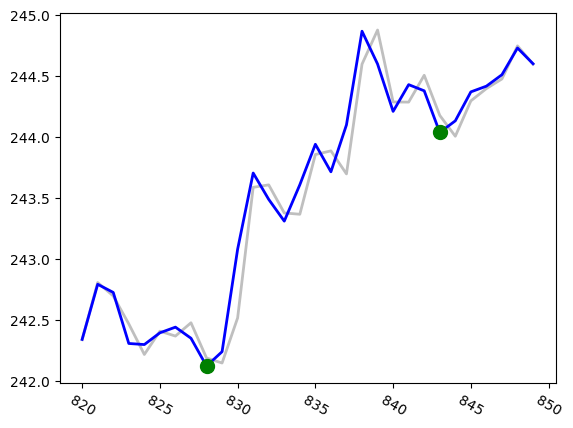

In [166]:
df2=df[-30:]

atr_window = 20
smooth_window_lenght = 6
polyorder = 4  # Must be less than window_lenght
distance = 5
width = 3

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=atr_window).mean()
df2["close_smooth"] = savgol_filter(df2.Close, smooth_window_lenght, polyorder)

atr = df2.atr.iloc[-1] # all the first atrs are NaN
peaks_idx, _ = find_peaks(df2.close_smooth, distance = distance, width = width, prominence=atr)
troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = distance, width = width, prominence=atr)

print(peaks_idx)
print(troughs_idx)

# PLOT
fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

plt.show()

[]
[8]
0


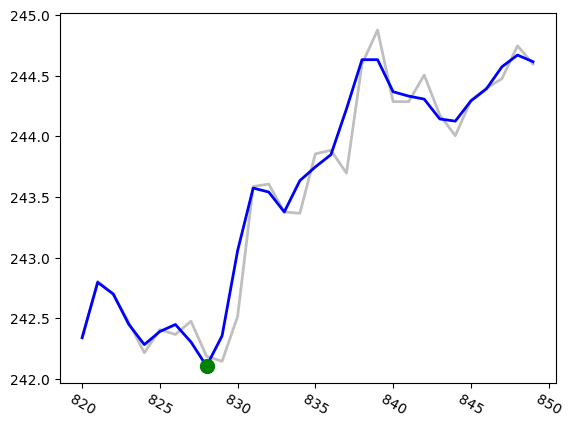

,datetime_est,Open,High,Low,Close,Volume,atr,close_smooth
820,2022-09-16 13:30:00-04:00,242.476,242.897,242.276,242.337,2.1108,NaN,242.340864
821,2022-09-16 13:35:00-04:00,242.347,242.957,242.276,242.806,2.3160,NaN,242.796370
822,2022-09-16 13:40:00-04:00,242.807,242.877,242.566,242.696,1.7640,NaN,242.701119
823,2022-09-16 13:45:00-04:00,242.697,242.717,242.356,242.467,1.4748,NaN,242.450626
824,2022-09-16 13:50:00-04:00,242.466,242.477,242.206,242.216,1.6956,NaN,242.283383
825,2022-09-16 13:55:00-04:00,242.226,242.497,242.146,242.407,1.8492,NaN,242.391551
826,2022-09-16 14:00:00-04:00,242.426,242.477,242.166,242.367,1.8024,NaN,242.449086
827,2022-09-16 14:05:00-04:00,242.356,242.536,242.276,242.476,1.5816,NaN,242.304957
828,2022-09-16 14:10:00-04:00,242.487,242.567,242.146,242.187,1.6344,NaN,242.106697
829,2022-09-16 14:15:00-04:00,242.196,242.417,242.056,242.146,1.8600,NaN,242.355807


In [165]:
df2=df[-30:]

atr_window = 5
smooth_window_lenght = 8
polyorder = 4  # Must be less than window_lenght

## Take the rolling atr so the yaxis doesn't shake too much 
df2["atr"] = ta.atr(high=df2.High, low=df2.Low, close=df2.Close)
df2["atr"] = df2.atr.rolling(window=atr_window).mean()
df2["close_smooth"] = savgol_filter(df2.Close, smooth_window_lenght, polyorder)

atr = df2.atr.iloc[-1] # all the first atrs are NaN
peaks_idx, _ = find_peaks(df2.close_smooth, prominence=atr)
troughs_idx, _ = find_peaks(-1*df2.close_smooth, prominence=atr)

'''
Check if we are on a up trend
'''
up_run_length = 0
up_run = True
while up_run:
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break

    peaks1 = df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]]
    peaks2 = df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]]

    troughs1 = df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]]
    troughs2 = df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]
    
    if peaks1 > peaks2 and troughs1 > troughs2:
        up_run_length += 1
    else:
        up_run = False 

'''
Set background color
'''
if up_run_length > 0:
    ax.set_facecolor('azure')  
else:
    ax.set_facecolor("white")

print(peaks_idx)
print(troughs_idx)
print(up_run_length)

# PLOT #
fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)
plt.show()
df2